# Perceptron Classification on the MNIST Dataset

In this example, we demonstrate how to:

- Load and preprocess the MNIST dataset
- Implement a Perceptron classifier from scratch using NumPy
- Train a binary and multiclass (One-vs-Rest) Perceptron
- Evaluate the model using classification accuracy
- Analyze the limitations of linear classifiers on image data

---

## Example: MNIST Dataset

### Overview

The **MNIST dataset** consists of **handwritten digits from 0 to 9**, where each digit is represented as a **28 × 28 grayscale image**.  
Each image is flattened into a 784-dimensional feature vector for use in standard machine learning algorithms.

---

### Data source (Kaggle):
https://www.kaggle.com/datasets/hojjatk/mnist-dataset

---

### Dataset Content

The MNIST dataset contains a total of **70,000 labeled images**, split into:

- **Training set:** 60,000 examples  
- **Test set:** 10,000 examples  

Each sample consists of:

- **Input:** a 28 × 28 grayscale image of a handwritten digit  
- **Label:** an integer in {0, 1, ..., 9}

In the CSV files, where:

- The **first column** is the digit label  
- The remaining **784 columns** correspond to pixel intensity values (0–255)

---

### Preprocessing

Before training the model, the data is preprocessed as follows:

- Each image is flattened into a vector of length 784
- Pixel values are normalized to the range **[0, 1]** by dividing by 255
- Labels are kept as integers for multiclass classification

---

### Learning Task and Output

The learning task is a **supervised multiclass classification problem**:

> Given an input image of a handwritten digit, predict which digit (0–9) it represents.

In this notebook:

- The **input** is a normalized 784-dimensional feature vector
- The **output** of the Perceptron model is a **predicted class label** in {0, 1, ..., 9}
- The model is evaluated using **classification accuracy** on the test set

The MNIST dataset provides a clear and interpretable benchmark for understanding the strengths and limitations of linear classifiers such as the Perceptron, and motivates the transition to more expressive models like multi-layer perceptrons (MLPs).

In [9]:
from perceptron import PerceptronBinary, PerceptronOVR

In [10]:
import pandas as pd
import numpy as np

train_df = pd.read_csv("mnist_train.csv", header= 0)
test_df  = pd.read_csv("mnist_test.csv", header= 0)

y_train = train_df.iloc[:, 0].values     
X_train = train_df.iloc[:, 1:].values    

y_test = test_df.iloc[:, 0].values          
X_test = test_df.iloc[:, 1:].values         

X_train = X_train.astype(np.float32) / 255.0
X_test  = X_test.astype(np.float32) / 255.0


In [11]:
print(train_df.shape)
print(test_df.shape)


(60000, 785)
(10000, 785)


In [12]:
# filter 0 & 1
train_mask = (y_train == 0) | (y_train == 1)
test_mask  = (y_test  == 0) | (y_test  == 1)

X_train_bin = X_train[train_mask]
y_train_bin = y_train[train_mask]
X_test_bin  = X_test[test_mask]
y_test_bin  = y_test[test_mask]

# mapping {0,1} to {-1, +1}
y_train_bin = np.where(y_train_bin == 1, 1, -1)
y_test_bin  = np.where(y_test_bin  == 1, 1, -1)


In [13]:
ovr_clf = PerceptronOVR(
    n_classes=10,
    n_features=784,
    lr=0.001,
    n_epochs=3
)

ovr_clf.fit(X_train, y_train)

y_pred = ovr_clf.predict(X_test)
accuracy = (y_pred == y_test).mean()
print("Test accuracy:", accuracy)


Training classifier for class 0 vs rest
Epoch 1/3, errors = 975
Epoch 2/3, errors = 775
Epoch 3/3, errors = 728

Training classifier for class 1 vs rest
Epoch 1/3, errors = 969
Epoch 2/3, errors = 783
Epoch 3/3, errors = 778

Training classifier for class 2 vs rest
Epoch 1/3, errors = 2132
Epoch 2/3, errors = 1893
Epoch 3/3, errors = 1882

Training classifier for class 3 vs rest
Epoch 1/3, errors = 2552
Epoch 2/3, errors = 2344
Epoch 3/3, errors = 2263

Training classifier for class 4 vs rest
Epoch 1/3, errors = 1826
Epoch 2/3, errors = 1540
Epoch 3/3, errors = 1466

Training classifier for class 5 vs rest
Epoch 1/3, errors = 2992
Epoch 2/3, errors = 2599
Epoch 3/3, errors = 2524

Training classifier for class 6 vs rest
Epoch 1/3, errors = 1417
Epoch 2/3, errors = 1208
Epoch 3/3, errors = 1186

Training classifier for class 7 vs rest
Epoch 1/3, errors = 1649
Epoch 2/3, errors = 1484
Epoch 3/3, errors = 1441

Training classifier for class 8 vs rest
Epoch 1/3, errors = 3972
Epoch 2/3, e

In [22]:
# fix label convention: {-1,+1} -> {0,1}
y_train_bin = ((y_train_bin + 1) // 2).astype(int)
y_test_bin  = ((y_test_bin + 1) // 2).astype(int)

print("unique labels:", np.unique(y_train_bin))
assert set(np.unique(y_train_bin)) == {0, 1}

perc = PerceptronBinary(
    n_features=X_train_bin.shape[1],
    lr=0.01,
    n_epochs=10
)

perc.fit(X_train_bin, y_train_bin)

y_pred_test = perc.predict(X_test_bin)
accuracy = np.mean(y_pred_test == y_test_bin)
print("Binary Perceptron accuracy (0 vs 1):", accuracy)



unique labels: [0 1]
Epoch 1/10, errors = 45
Epoch 2/10, errors = 18
Epoch 3/10, errors = 22
Epoch 4/10, errors = 13
Epoch 5/10, errors = 19
Epoch 6/10, errors = 10
Epoch 7/10, errors = 15
Epoch 8/10, errors = 18
Epoch 9/10, errors = 2
Epoch 10/10, errors = 0
Binary Perceptron accuracy (0 vs 1): 0.9995271867612293


Visualize data：Plot n MNIST samples with labels.

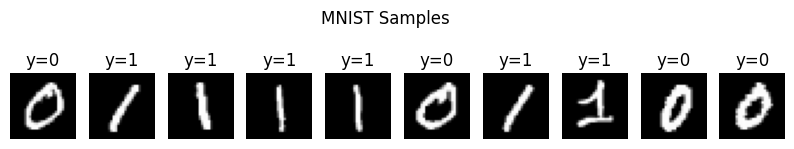

In [28]:
import matplotlib.pyplot as plt
import numpy as np

def plot_mnist_samples(X, y, n=10):
    """
    Plot n MNIST samples with labels.
    X: (N, 784)
    y: (N,)
    """
    plt.figure(figsize=(n, 2))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        plt.imshow(X[i].reshape(28, 28), cmap="gray")
        plt.title(f"y={y[i]}")
        plt.axis("off")
    plt.suptitle("MNIST Samples")
    plt.show()

plot_mnist_samples(X_train_bin, y_train_bin, n=10)


In [23]:
# train on a subset of the training data = 10000 samples
n_train_subset = 10000
X_train_sub = X_train[:n_train_subset]
y_train_sub = y_train[:n_train_subset]

ovr_clf = PerceptronOVR(n_classes=10, n_features=784, lr=0.001, n_epochs=3)
ovr_clf.fit(X_train_sub, y_train_sub)

y_test_pred = ovr_clf.predict(X_test)
accuracy = np.mean(y_test_pred == y_test)
print("Multiclass Perceptron accuracy (subset trained):", accuracy)



Training classifier for class 0 vs rest
Epoch 1/3, errors = 226
Epoch 2/3, errors = 155
Epoch 3/3, errors = 125

Training classifier for class 1 vs rest
Epoch 1/3, errors = 220
Epoch 2/3, errors = 160
Epoch 3/3, errors = 156

Training classifier for class 2 vs rest
Epoch 1/3, errors = 445
Epoch 2/3, errors = 374
Epoch 3/3, errors = 341

Training classifier for class 3 vs rest
Epoch 1/3, errors = 502
Epoch 2/3, errors = 422
Epoch 3/3, errors = 406

Training classifier for class 4 vs rest
Epoch 1/3, errors = 391
Epoch 2/3, errors = 285
Epoch 3/3, errors = 274

Training classifier for class 5 vs rest
Epoch 1/3, errors = 556
Epoch 2/3, errors = 431
Epoch 3/3, errors = 396

Training classifier for class 6 vs rest
Epoch 1/3, errors = 276
Epoch 2/3, errors = 209
Epoch 3/3, errors = 197

Training classifier for class 7 vs rest
Epoch 1/3, errors = 339
Epoch 2/3, errors = 264
Epoch 3/3, errors = 258

Training classifier for class 8 vs rest
Epoch 1/3, errors = 783
Epoch 2/3, errors = 636
Epoch 3

Visualize the learned weight vector of a PerceptronBinary：

Red regions indicate pixels that contribute positively to predicting class 1,
while blue regions indicate pixels that suppress the prediction.
This visualization reflects the linear nature of the Perceptron classifier.

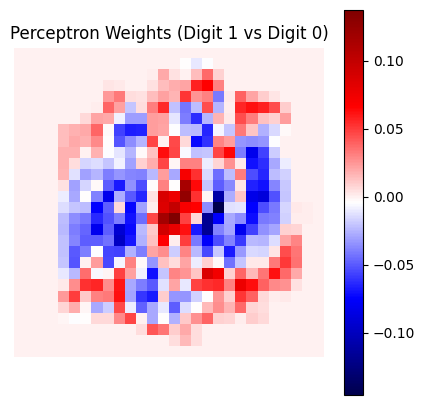

In [25]:
def plot_perceptron_weights(perceptron, title="Perceptron Weight Vector"):
    """
    Visualize the learned weight vector of a PerceptronBinary.
    """
    w = perceptron.w
    if w.size != 784:
        raise ValueError("Weight visualization assumes MNIST (784 features).")

    plt.figure(figsize=(5, 5))
    plt.imshow(w.reshape(28, 28), cmap="seismic")
    plt.colorbar()
    plt.title(title)
    plt.axis("off")
    plt.show()

plot_perceptron_weights(
    perc,
    title="Perceptron Weights (Digit 1 vs Digit 0)"
)


In [26]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import pandas as pd

def plot_confusion_matrix(y_true, y_pred, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)
    df_cm = pd.DataFrame(cm)

    plt.figure(figsize=(5, 4))
    sns.heatmap(df_cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.title(title)
    plt.show()


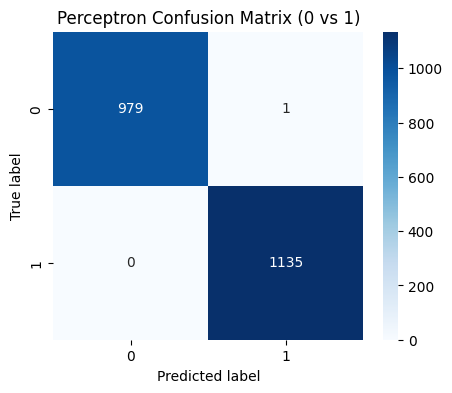

In [27]:
plot_confusion_matrix(
    y_test_bin,
    y_pred_test,
    title="Perceptron Confusion Matrix (0 vs 1)"
)